In [2]:
%load_ext autoreload
%autoreload 2

## Les Modules 

In [3]:
import tensorflow as tf
import pandas as pd
import scipy
import sklearn
import pyro
import torch

In [4]:
import numpy as np
import math
import random
np.random.seed(0)
import matplotlib.pyplot as plt
from matplotlib.pyplot import*

import time
from tqdm import tqdm
from sklearn.datasets import make_blobs,make_circles
from sklearn.metrics import accuracy_score

from IPython.display import clear_output
from IPython.display import clear_output, display

## Couche du reseaux [C_0,C_1,C_2,...,C_finale],chaque couche contient le nombre de neurones¶

In [5]:
def coucheDense(fonction_seuil,nombre_de_couche=1,nombre_de_neurones=1):
    
    couche_réseau={}
    for i,j in zip([k for k in range(1,nombre_de_couche+1)],[nombre_de_neurones for k in range(nombre_de_couche)]):
        couche_réseau[f'C{i}']=j 
        couche_réseau[f'f{i}']=fonction_seuil[0]
        couche_réseau[f'df{i}']=fonction_seuil[1]
        
    return couche_réseau

In [6]:
def réseau(*Couche):
    
    Couche=list(Couche)
    L=len(Couche)
    couche_réseau={}
    
    couche_réseau[f'C{1}']=Couche[0][f'C{1}'] 
    couche_réseau[f'f{1}']=Couche[0][f'f{1}'] 
    couche_réseau[f'df{1}']=Couche[0][f'df{1}'] 
    
    k=2
    if L>1:
        for j in range(1,L-1):
            n2=len(Couche[j])//3
            for i in range(1,n2+1):
                couche_réseau[f'C{k}']=Couche[j][f'C{i}'] 
                couche_réseau[f'f{k}']=Couche[j][f'f{i}'] 
                couche_réseau[f'df{k}']=Couche[j][f'df{i}'] 
                k=k+1
            
    if L>2:
        couche_réseau[f'C{k}']=Couche[L-1][f'C{1}'] 
        couche_réseau[f'f{k}']=Couche[L-1][f'f{1}'] 
        couche_réseau[f'df{k}']=Couche[L-1][f'df{1}']
    
    return couche_réseau

## Initialisation des paramettrées:Poides de biais(W_i,B_i , i=1,2,....,nombre de couches)

In [40]:
def initialisation(réseau1,X_train):
    
    np.random.seed(0)
    n1=len(réseau1)//3
    m=[réseau1[f'C{i}'] for i in range(1,n1+1)]
    m.insert(0,X_train.shape[0]) 
    print(f'L\'architecture du réseau:{m}')
    W=[np.random.randn(m[i+1],m[i])*np.sqrt(2/m[i]) for i in range(len(m)-1)]
    paramètre1={f'W{i+1}':W[i] for i in range(len(W))}
    b=[np.zeros((m[j],1)) for j in range(1,len(m))]
    for i in range(len(b)):
        paramètre1[f'b{i+1}']=b[i] 
    m.pop(0)
    
    #for i,j in zip(paramètre1.keys(),paramètre1.values()):print(f'dim({i})={j.shape}')
    return paramètre1

## Les fonctions d'activations: chousier pour les couches caché et la couche de sortie

In [12]:
def fonction_activation(X,alpha=0):

    def relu(x):
        return np.where(x>=0,x,0)
    def D_relu(x):
        return np.where(x>0,1,0)                    
    
    def Leaky_relu(x):
        return np.where(x>=0,x,alpha*x)
    def D_Leaky_relu(x):
        return np.where(x>0,1,alpha)                     # alpha>=0 : 0 pour est le ReLu classique
        
    def ELU(x):
        return np.where(x>=0,x,alpha*(np.exp(x)-1))
    def D_ELU(x):
        return np.where(x>0,1,alpha*np.exp(x))          # alpha>=0 : 0 pour est le ReLu classique

    def sigmoide(x):
        return 1/(1+np.exp(-x))
    def D_sigmoide(x):
        return sigmoide(x)*(1-sigmoide(x))

    def swish(x):
        return x*sigmoide(-alpha*x)                      # beta>0 est le ReLu classique
    def D_swish(x):
        return sigmoide(-alpha*x)-alpha*x*D_sigmoide(-alpha*x)

    def sah(x):
        return np.where(x==0,alpha,alpha*((-1+np.sqrt(x**2+x+1))/x))    # beta>0 
    def D_sah(x):
        return np.where(x==0,-alpha*0.75,alpha*(-x-2+np.sqrt(x**2+x+1))/2*x**2*np.sqrt(x**2+x+1))  
    
    def id(x):
        return x                     
    def D_id(x):
        return 1

    def tanh(x):
        return np.tanh(x)                    
    def D_tanh(x):
        return 1-(np.tanh(x))**2  
        
    def softmax(x,p=1):
        x = x -np.max(x, axis=0, keepdims=True)  # stabilité numérique
        a= (np.exp(x))**p
        return a / (np.sum(a, axis=0, keepdims=True))**(1/p)    

    def D_softmax(x):
        return np.diag(softmax(x))- np.outer(softmax(x), softmax(x))
    
    fonction=['id','swish','relu','Leaky_relu','ELU','tanh','sigmoide','softmax','sah']
    expression=[id ,swish,relu,Leaky_relu,ELU,tanh,sigmoide,softmax,sah]
    Dérivée=[D_id ,D_swish,D_relu,D_Leaky_relu,D_ELU,D_tanh,D_sigmoide,D_softmax,D_sah]
    
    fonction_activations={i:j for i,j in zip(fonction,expression)}
    Dérivée_fonction_activations={i:j for i,j in zip(fonction,Dérivée)}
    
    expresion_et_dérivée=[fonction_activations[X],Dérivée_fonction_activations[X]]
    
    return expresion_et_dérivée

## Vérification rapide dimensions des données d'entrainement du réseau

In [10]:
def DimensionDonnées(X_train,y_train='non',X_test='non',y_test='non'):
    if type(X_train)!=str:print('dim X_train=',X_train.shape)
    if type(y_train)!=str:print('dim y_train=',y_train.shape)              
    if type(X_test)!=str:print('dim X_test',X_test.shape)
    if type(y_test)!=str:print('dim y_test=',y_test.shape)
    return 
    
def DimensionParamètres(nom_paramètre):
    for i,j in zip(nom_paramètre.keys(),nom_paramètre.values()):print(f'dim({i})={j.shape}')
    return 

## Normalisation des données du Data_set

In [11]:
def normalisation(nom,X=np.array((1,1))):
    def min_max():
        if X.max()-X.min()==0:
            X_normaliser=X
        else:
            X_normaliser=(X-X.min())/(X.max()-X.min())
        return X_normaliser
    def standarlisation():
        moy=np.mean(X)
        ecart_type=(X.var())**0.5
        X_standarliser=(X-moy)/ecart_type 
        return X_standarliser
    def ID():
        return X
    return eval(nom)()

## Les fonctions de regularisation ainsi que ses Dérivée: pour éviter overfitting et underfitting

In [12]:
def regularisation(paramètres1,pénalisation,alpha=0,beta=0):
    
    regularisation1,gradient_regularisation={},{}
    def lasso():
        Gradient_regularisation={}
        for i in range(1,len(paramètres1)//2+1):
            Gradient_regularisation[f'dRW{i}']=alpha*np.sign(paramètres1[f'W{i}'])
            Gradient_regularisation[f'dRb{i}']=0#alpha*np.sign(paramètres1[f'b{i}']) 
        return Gradient_regularisation
    def ridge():
        Gradient_regularisation={}
        for i in range(1,len(paramètres1)//2+1):
            Gradient_regularisation[f'dRW{i}']=2*alpha*paramètres1[f'W{i}']
            Gradient_regularisation[f'dRb{i}']=0#2*alpha*paramètres1[f'b{i}']
        return Gradient_regularisation
    def elasticnet():
        Gradient_regularisation={}
        for i in range(1,len(paramètres1)//2+1):
            Gradient_regularisation[f'dRW{i}']=alpha*(beta*np.sign(paramètres1[f'W{i}'])+(1-beta)*0.5*paramètres1[f'W{i}'])
            Gradient_regularisation[f'dRb{i}']=0#alpha*(beta*np.sign(paramètres1[f'b{i}'])+(1-beta)*0.5*paramètres1[f'b{i}'])
        return Gradient_regularisation
    
    L1,L2=0,0
    for i in range(1,len(paramètres1)//2+1):
        L1=L1+np.sum(np.abs(paramètres1[f'W{i}']))
        L2=L2+np.sum(paramètres1[f'W{i}']**2)
    liste1=['lasso','ridge','elasticnet']
    liste2=[alpha*L1,beta*L2,alpha*(beta*L1+0.5*(1-beta)*L2)]
    
    regularisation1={i:j for i,j in zip(liste1,liste2)}
    gradient_regularisation={i:j for i,j in zip (liste1,[lasso(),ridge(),elasticnet()])}
    
    return regularisation1[pénalisation] ,gradient_regularisation[pénalisation]

## Variation du pas de descent du gradient:pas_gradient

In [14]:
def PasGradient(noms,gamma):
    def PD_exp(i,pas):
        pas=pas*np.exp(-gamma*i)
        return pas
    Pas_gradient={'PD_exp':PD_exp}
    return Pas_gradient[noms]


In [15]:
PasGradient('PD_exp',0)(0,0.01)

0.01

## Forward propagation:Activations des sortie des couches

In [17]:
def Forword_propagation(X_train,réseau1,paramètres):                           #fk : fonction d'activation de  lacouches cache k 
    
    sortie_linéaire={'Z0':X_train}
    activation={'A0':X_train}
    
    n1=len(paramètres)//2
    
    for i in range(1,n1+1):
        sortie_linéaire[f'Z{i}']=np.dot(paramètres[f'W{i}'],activation[f'A{i-1}'])+paramètres[f'b{i}']
        activation[f'A{i}']=réseau1[f'f{i}'](sortie_linéaire[f'Z{i}'])  
        
    #for i,j in zip(sortie_linéaire.keys(),sortie_linéaire.values()):print(f'dim({i})={j.shape}')
    #for i,j in zip(activation.keys(), activation.values()):print(f'dim({i})={j.shape}')
    
    return sortie_linéaire,activation

## Back-propagation: Calcule des gradient couche par couche de la C_final vers C_1

In [18]:
def Back_propagation(réseau1,y_test,paramètres1,sortie_linéaire1,Activation1,regularisation1,fonction_perte1):

    GR=regularisation1[1]
    L=len(paramètres1)//2
    m=y_test.shape[1]
    
    Gradients={}
    if fonction_perte1[0]=='ECB' : 
        Dk=(1/m)*(Activation1[f'A{L}']-y_test)
    elif fonction_perte1[0]=='ECBM' :
        Dk=(1/m)*(Activation1[f'A{L}']-y_test)
    else:
        Dk=(2/m)*(Activation1[f'A{L}']-y_test)
    
    for k in range(L,0,-1):
        Gradients[f'dW{k}']=np.dot(Dk,Activation1[f'A{k-1}'].T)+GR[f'dRW{k}']
        Gradients[f'db{k}']=np.sum(Dk,axis=1,keepdims=True)+GR[f'dRb{k}']
        if k!=1: Dk=np.dot(paramètres1[f'W{k}'].T,Dk)*réseau1[f'df{k-1}'](sortie_linéaire1[f'Z{k-1}'])
            
        #for i,j in zip(gradients.keys(),gradients.values()):print(f'dim({i})={j.shape}')

    return Gradients

## Modification des paramètres du réseau

In [21]:
def Descente_gradient(paramètres1,gradients1,pas_gradient):
    
    n1=len(paramètres1)//2
    for i in range(1,n1+1):
        paramètres1[f'W{i}']=paramètres1[f'W{i}']-pas_gradient*gradients1[f'dW{i}']
        paramètres1[f'b{i}']=paramètres1[f'b{i}']-pas_gradient*gradients1[f'db{i}']

    return paramètres1

## Gradient stochastique

In [22]:
def batch(X,y,n):
    batchs={}
    k=0
    for i in range(X.shape[1]//n):
        batchs[f'Xbatch{i}']=X[:,k:k+n]
        batchs[f'Ybatch{i}']=y[:,k:k+n]
        k=k+n
    return batchs
    

In [2]:
def batch_echantillon(X_train,y_train,taille_batch):
    n=[np.random.randint(0,X_train.shape[1]-1) for j in range(taille_batch)]
    Xbatch=np.array([X_train[:,i:i+1] for i in n])
    Ybatch=np.array([y_train[:,i:i+1] for i in n])
    Xbatch=Xbatch.reshape(X_train.shape[0],Xbatch.shape[0])
    Ybatch=Ybatch.reshape(y_train.shape[0],Ybatch.shape[0])
    return Xbatch,Ybatch

## Fonction perte du réseau

In [37]:
def evaluation_perte(nom_foncton,epsilon=1e-16):
    
    def MSE(y_test1,Activation1,regularisation1=[0]):
        EMQ=(Activation1[f'A{len(Activation1)-1}']-y_test1)**2+regularisation1[0]
        return EMQ.mean()
        
    def MAE(y_test1,Activation1,regularisation1=[0]):
        EMA=np.abs(y_test1-Activation1[f'A{len(Activation1)-1}'])+regularisation1[0]
        return EMA.mean()
        
    def ECB(y_test1,Activation1,regularisation1=[0]):
        log_loss=(y_test1*np.log(Activation1[f'A{len(Activation1)-1}']+epsilon))+((1-y_test1)*np.log(1-Activation1[f'A{len(Activation1)-1}']+epsilon))+regularisation1[0]
        return -np.sum(log_loss)/(y_test1.shape[1])
    
    def ECBM(y_test1, Activation1, regularisation1=[0]):
        A_final = Activation1[f'A{len(Activation1)-1}']
        log_loss = np.sum(y_test1 * np.log(A_final + epsilon), axis=0)  
        return -np.mean(log_loss) + regularisation1[0]

    liste1=['MSE','MAE','ECB','ECBM']
    liste2=[MSE,MAE,ECB,ECBM]
    
    Fonction_perte1={i:j for i,j in zip(liste1,liste2)}
    
    return Fonction_perte1[nom_foncton]

In [38]:
def fonction_perte(nom,epsilon=0.5):
    return [nom,epsilon]


## fonction score du réseau:Performance du modèle

In [34]:
def performance(nom_foncton):
    
    def coefR2(y_test1,sortie_réseau):
        sortie2=sortie_réseau[f'A{len(sortie_réseau)-1}']
        A=(sortie2-y_test1)**2
        B=(y_test1-y_test1.mean())**2
        return 1-(A.mean()/B.mean())
        
    def Accuracy_score(y_test, sortie_réseau, seuil=0.5):
            sortie2=sortie_réseau[f'A{len(sortie_réseau)-1}']
            predictions=(sortie2 > seuil).astype(int)
            return np.mean(predictions == y_test)
    def Accuracy_score_multiclasse(y_test, sortie_réseau, seuil=0.5):
            sortie2=sortie_réseau[f'A{len(sortie_réseau)-1}']
            a=np.argmax(sortie2,axis=0)
            b=np.argmax(y_test,axis=0)
            return np.mean(a==b)
        
    liste1=['coefR2','Accuracy_score','Accuracy_score_multiclasse']
    liste2=[coefR2,Accuracy_score,Accuracy_score_multiclasse]
    
    fonction_performance={i:j for i ,j in zip(liste1,liste2)}
    
    return fonction_performance[nom_foncton]


## Actualisation du modele

In [62]:
def actualisation(modele):
    para=(modele.couches[0],modele.loss[0],modele.regularisation[:],modele.optimiseur[:],modele.score[0])
    return list(para)[:]

In [63]:
def recupe(*X):
    liste=list(X)
    n1=len(liste)
    X_train,y_train,X_test,y_test='non','non','non','non'
    if n1==2:
        X_train=liste[0]
        y_train=liste[1]
    elif n1==4:
        X_train=liste[0]
        y_train=liste[1]
        X_test=liste[2]
        y_test=liste[3]
    return X_train,y_train,X_test,y_test

## Les fonction à corriger

## Mon Réseau de neurones artificiel(ANN)

In [64]:
def RéseauDeNeurone(X_train,y_train,X_test,y_test,réseau,fonction_perte1,evaluation_performance,pénalisation1='non',pas_gradient=0.1,nombre_iter=30,pas_sauvegade=10):

    paramètres=initialisation(Réseau,X)
    
    coût1,Performance_réseau1=[],[]                                                        # sur les données du trainset
    coût2,Performance_réseau2=[],[]                                                        # sur le les doonnées testset
    temps_écouler=[]                                                                       #temps écouler en 10 iteration d'entrainement
    n1=len(paramètres)//2
    temps_initiale=time.time()
    paramètres_evoluant={}
    pas=pas_gradient
    
    print('classement des neurones par couche[1er_couche,2ème_couche,...]:',[réseau[f'C{i}'] for i in range(1,n1+1)])
    
    if pénalisation1=='non' : pénalité=[0,0]   
    else: pénalité=regularisation(paramètres,str(pénalisation1[0]),pénalisation1[1],pénalisation1[2])
        
    for i in tqdm(range(nombre_iter+1)):
        sortie_linéaire1,activation1=Forword_propagation(X_train,réseau,paramètres)
        sortie_linéaire2,activation2=Forword_propagation(X_test,réseau,paramètres)
        n2=i%pas_sauvegade
        
        if n2==0:                                                             #enregistre le court chaque 10 intération
            n3=i//pas_sauvegade
            paramètres_evoluant[f'P{n3}']=paramètres.copy()
            coût1.append(evaluation_perte(str(fonction_perte1[0]),fonction_perte1[1])(y_train,activation1,pénalité))
            Performance_réseau1.append(evaluation_performance(y_train,activation1))  
            
            if type(y_test)!=str: 
                coût2.append(evaluation_perte(str(fonction_perte1[0]),fonction_perte1[1])(y_test,activation2,pénalité))
                Performance_réseau2.append(evaluation_performance(y_test,activation2))        
            temps_écouler.append(time.time()-temps_initiale)
    
        Gradients=Back_propagation(Réseau,y_train,paramètres,sortie_linéaire1,activation1,pénalité,fonction_perte1)
        paramètres=Descente_gradient(paramètres,Gradients,pas)
        pas=PasGradient('pas_décroissante',1/nombre_iter)(i,pas)
    
   
    score=evaluation_performance(y_train,activation1)
    print(f'le socre du modèle est de :{score:.2f}')
    
    return paramètres_evoluant,coût1,coût2,Performance_réseau1,Performance_réseau2,temps_écouler
    

## La frontière de decision où approximation

In [65]:
def frontière(Donnée_entrée,mom_du_réseau,paramètre_finale,precision):
    
    n1=len(paramètre_finale)//2
    
    Echontillon={f'X{i}':np.linspace(Donnée_entrée.min(),Donnée_entrée.max(),1000) for i in range(Donnée_entrée.shape[0])}
    
    if len(Echontillon)!=1 and type(precision)!=str:
        xf,yf=np.meshgrid(Echontillon['X0'],Echontillon['X1'])
        Sf1=[]
        
        for i,j in zip(xf,yf):
            Xf=np.array([i,j])
            activation=Forword_propagation(Xf,mom_du_réseau,paramètre_finale)[1]
            Sf1.append(activation[f'A{n1}'].flatten())
            
        Sf=np.array([Sf1[i] for i in range(len(Sf1))])
        decision=(np.abs(Sf-0.5)<precision).astype(int)
    elif len(Echontillon)==1 and type(precision)==str:                                                                    # pour l'approximtion des fonction 
        xf=np.meshgrid(Echontillon['X0'])
        xf=xf[0].reshape(1,xf[0].shape[0])
        activation=Forword_propagation(xf,mom_du_réseau,paramètre_finale)[1]
        yf=activation[f'A{n1}'].flatten()
        xf=xf.flatten()
        decision='approximation2D'
    else:
        #xf=Echontillon['X0']
        #xf=xf[0].reshape(1,xf[0].shape[0])
        activation=Forword_propagation(Donnée_entrée,mom_du_réseau,paramètre_finale)[1]
        yf=activation[f'A{n1}'].flatten()
        xf=0
        decision='approximation3D'

    return xf,yf,decision 

## initialisation des donnée de la foncction à approximé

In [2]:
def approximation(f,a,b,nbr_variale,taille_donnée,p_train=0.8,p_test=0):

    p_test=p_test+p_train
    donnée=np.zeros((nbr_variale,taille_donnée))
    for i in range(nbr_variale):
        donnée[i]=np.linspace(a,b,taille_donnée)
    x,y=0,0                                                                # donnée=np.random.uniform(a,b,(nbr_variale,taille_donnée))
    if nbr_variale==1:Y=f(donnée)
    else:
        x,y=np.meshgrid(donnée[0],donnée[1])
        Y=f(x,y).flatten()
        Y=Y.reshape(1,Y.shape[0])
        donnée=np.array([x.flatten(),y.flatten()])
        
    X=donnée[:,0:int(p_train*donnée.shape[1])]
    y_x=Y[:,0:int(p_train*Y.shape[1])]
    if p_train==1:X_test,X_pred, y_test='non','non','non'
    else: 
        X_test=donnée[:,int(p_train*donnée.shape[1]):int(p_test*donnée.shape[1])]
        y_test=Y[:,int(p_train*Y.shape[1]):int(p_test*Y.shape[1])]
        if p_test==1 : X_pred='non'
        else: X_pred=donnée[:,int(p_test*Y.shape[1]):]
    return X,y_x,X_test,y_test,X_pred,donnée


## Prédiction par le modèle

In [1]:
def prediction(X_pred,réseau,paramètre):
    n1=len(paramètre)//2
    activation=Forword_propagation(X_pred,réseau,paramètre)[1]
    return activation[f'A{n1}']>0.5,activation[f'A{n1}']

C:\Users\GEMSI\AppData\Local\Temp\ipykernel_11256\3532807509.py:19: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


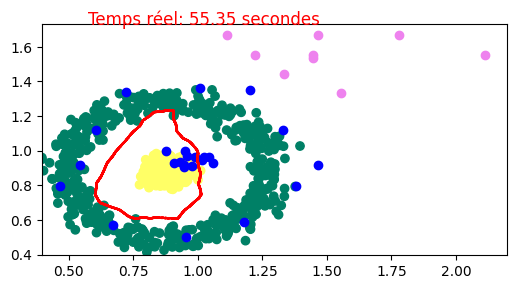

In [30]:
graphe(X,y_x,X_test,X_fiture,Réseau,paramètre,temps_ecouler,precision=1e-1,taille_frontière=1)

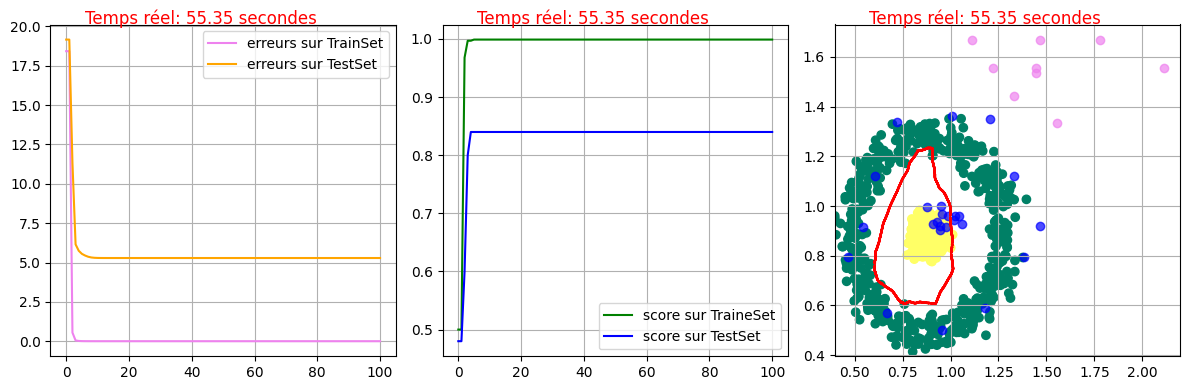

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:42<00:00, 21.14s/it]


In [31]:
Graphe_animée1(X,y_x,X_test,y_test,X_fiture,cout1,cout2,score1,score2,Réseau,paramètre,temps_ecouler,pas_iter=100,epsilon=1e-1) 

In [35]:
X=np.linspace(-1,1,100)
y_x=np.sin(X)
X=normalisation('min_max',X)
y_x=normalisation('min_max',y_x)
X.reshape(X.shape[0],1)
y_x.reshape(y_x.shape[0],1)



array([[0.        ],
       [0.00658737],
       [0.01337611],
       [0.02036344],
       [0.02754651],
       [0.03492239],
       [0.04248808],
       [0.05024048],
       [0.05817644],
       [0.0662927 ],
       [0.07458596],
       [0.08305284],
       [0.09168988],
       [0.10049355],
       [0.10946026],
       [0.11858636],
       [0.12786811],
       [0.13730173],
       [0.14688338],
       [0.15660913],
       [0.16647502],
       [0.17647703],
       [0.18661107],
       [0.196873  ],
       [0.20725865],
       [0.21776376],
       [0.22838406],
       [0.23911521],
       [0.24995282],
       [0.26089248],
       [0.27192973],
       [0.28306005],
       [0.2942789 ],
       [0.30558171],
       [0.31696387],
       [0.32842072],
       [0.3399476 ],
       [0.35153979],
       [0.36319257],
       [0.37490119],
       [0.38666086],
       [0.39846678],
       [0.41031414],
       [0.4221981 ],
       [0.43411381],
       [0.44605641],
       [0.45802103],
       [0.470

In [1]:
#!pip install tensorflow-datasets

In [2]:
#import tensorflow_datasets as tfds
#ds, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)


In [32]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalisation des pixels entre 0 et 1
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 89s 8us/step


In [118]:
#y_test#import h5py

In [424]:
a=np.array([[0.5,0.2]])

In [425]:
a,b=prediction(a.T,Réseau,paramètre)

In [426]:
print(f'{a[0,0]}:{b[0,0]:.2f}')

False:0.00


In [115]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("benjnb/cars-for-sale")

print("Path to dataset files:", path)

# Download latest version
#path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")

#print("Path to dataset files:", path)

ERROR! Session/line number was not unique in database. History logging moved to new session 597
Path to dataset files: C:\Users\GEMSI\.cache\kagglehub\datasets\benjnb\cars-for-sale\versions\2


In [209]:
y_x.shape

(1, 100)

In [36]:
!pip install kaggle

In [37]:
!kaggle competitions download -c dogs-vs-cats

AccŠs refus‚.


In [ ]:
A=np.ones((2,3))
B=2*np.ones((2,3))

In [1517]:
A/B

array([[0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5]])